epoch | batch loss
----------------------------
1 :  11.683059418808568
1000 :  4.351140044504669
2000 :  3.5743932881610396
3000 :  5.580249252306579
4000 :  3.74398307492882
5000 :  4.391807774706167
6000 :  4.4259870459799435
7000 :  4.091522908438262
8000 :  5.422227281918948
9000 :  4.215420270199124
10000 :  4.760430057490726
11000 :  3.2692098707564994
12000 :  5.872452825995411
13000 :  3.7220847181100845
14000 :  3.344450559532742
15000 :  2.96735313985088
16000 :  2.935812309245101
17000 :  3.882766902269646
18000 :  4.7770464698289095
19000 :  4.285008984232153
20000 :  3.956545059875024
21000 :  2.83030101616758
22000 :  5.180306259339035
23000 :  4.304724499385534
24000 :  3.6654428919254367
25000 :  3.5828210494298443
26000 :  2.692627466555047
27000 :  3.402155380575522
28000 :  1.989804698879971
29000 :  3.8524419186851584
30000 :  2.8591585193590494
entire training set loss =  4.014727763770904


/var/folders/hl/18z9x6cd0cs071nkgz798m6h0000gn/T/ipykernel_72265/3078591867.py:151: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_preds[i],  = a[L]


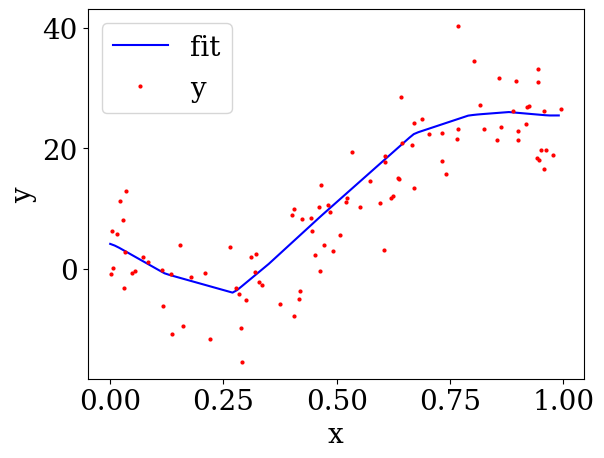

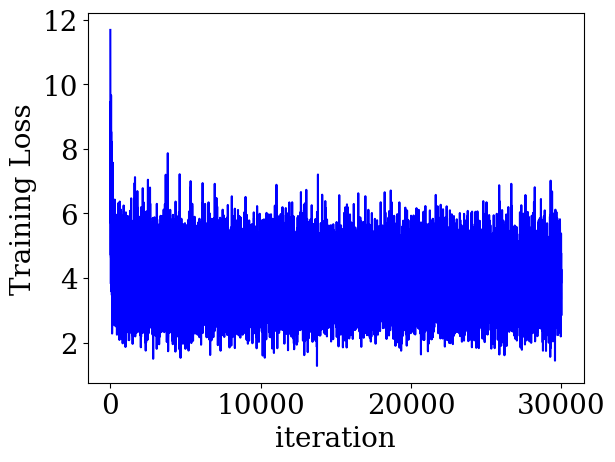

/var/folders/hl/18z9x6cd0cs071nkgz798m6h0000gn/T/ipykernel_72265/3078591867.py:180: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_preds[i],  = a[L]


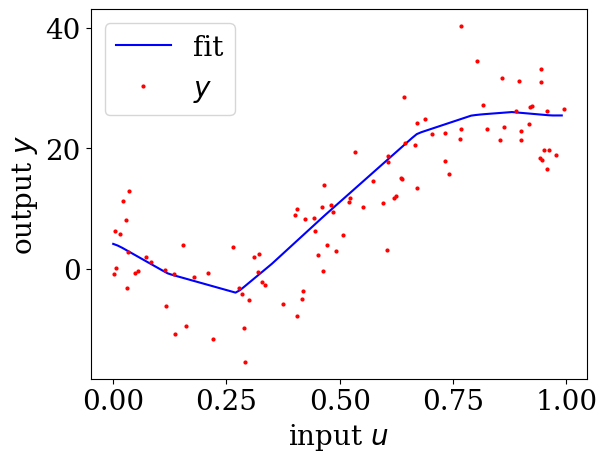

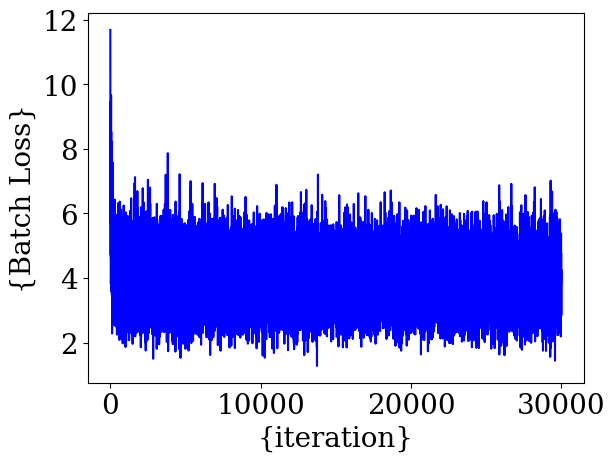

In [18]:
''' NeuralNetPurePython.py '''

import numpy as np
import matplotlib.pyplot as plt

def initialize(p, w_sig = 1):
    W, b = [[]]*len(p), [[]]*len(p)

    for l in range(1,len(p)):
       W[l]= w_sig * np.random.randn(p[l], p[l-1])
       b[l]= w_sig * np.random.randn(p[l], 1)
    return W,b

def list2vec(W,b):
    # converts list of weight matrices and bias vectors into one column vector
    b_stack = np.vstack([b[i] for i in range(1,len(b))] )
    W_stack = np.vstack([W[i].flatten().reshape(-1,1) for i in range(1,len(W))])
    vec = np.vstack([b_stack, W_stack])
    return vec
#%%
def vec2list(vec, p):
    # converts vector to weight matrices and bias vectors
    W, b = [[]]*len(p),[[]]*len(p)
    p_count = 0

    for l in range(1,len(p)): # construct bias vectors
        b[l] = vec[p_count:(p_count+p[l])].reshape(-1,1)
        p_count = p_count + p[l]

    for l in range(1,len(p)): # construct weight matrices
        W[l] = vec[p_count:(p_count + p[l]*p[l-1])].reshape((p[l], p[l-1]))
        p_count = p_count + (p[l]*p[l-1])

    return W, b
#%%
def RELU(z,l):
    # RELU activation function: value and derivative
    if l == L: return z, np.ones_like(z) # if last layer return identity
    else:
        val = np.maximum(0,z) # RELU function element-wise
        J = np.array(z>0, dtype = float) # derivative of RELU element-wise
        return val, J


#%%
def huber_loss_fn(y, g, delta=1.0):

    error = g - y
    abs_error = np.abs(error)

    # Huber loss: quadratic for small errors, linear for large errors
    if abs_error <= delta:
        # Quadratic region: 0.5 * error^2
        loss = 0.5 * error**2
        gradient = error
    else:
        # Linear region: delta * (|error| - 0.5 * delta)
        loss = delta * (abs_error - 0.5 * delta)
        gradient = delta * np.sign(error)

    return loss, gradient

def loss_fn(y,g):

    return huber_loss_fn(y, g)
    # return (g - y)**2, 2 * (g - y)


#%%
def feedforward(x,W,b):
    a, z, gr_S = [0]*(L+1), [0]*(L+1), [0]*(L+1)

    a[0] = x.reshape(-1,1)
    for l in range(1,L+1):
        z[l] = W[l] @ a[l-1] + b[l] # affine transformation
        a[l], gr_S[l] = S(z[l],l) # activation function
    return a, z, gr_S

#%%
def backward(W,b,X,y):
    n =len(y)
    delta = [0]*(L+1)
    dC_db, dC_dW = [0]*(L+1), [0]*(L+1)
    loss=0

    for i in range(n): # loop over training examples
        a, z, gr_S = feedforward(X[i,:].T, W, b)
        cost, gr_C = loss_fn(y[i], a[L]) # cost i and gradient wrt g
        loss += cost/n

        delta[L] = gr_S[L] @ gr_C

        for l in range(L,0,-1): # l = L,...,1
            dCi_dbl = delta[l]
            dCi_dWl = delta[l] @  a[l-1].T

            # ---- sum up over samples ----
            dC_db[l] = dC_db[l] + dCi_dbl/n
            dC_dW[l] = dC_dW[l] + dCi_dWl/n
            # -----------------------------

            delta[l-1] =  gr_S[l-1] * W[l].T @ delta[l]

    return dC_dW, dC_db, loss



#%%
# import data
data = np.genfromtxt('data/polyreg.csv',delimiter=',')
X = data[:,0].reshape(-1,1)
y = data[:,1].reshape(-1,1)

    # Network setup
p = [X.shape[1],20,20,1] # size of layers
L = len(p)-1             # number of layers
W,b = initialize(p) # initialize weight matrices and bias vectors
S = RELU

batch_size = 20
lr = 0.005
beta = list2vec(W,b)
loss_arr = []
n = len(X)
num_epochs = 30000
print("epoch | batch loss")
print("----------------------------")
for epoch in range(1,num_epochs+1):
    batch_idx = np.random.choice(n,batch_size)
    batch_X = X[batch_idx].reshape(-1,1)
    batch_y=y[batch_idx].reshape(-1,1)
    dC_dW, dC_db, loss = backward(W,b,batch_X,batch_y)
    d_beta = list2vec(dC_dW,dC_db)
    loss_arr.append(loss.flatten()[0])
    if(epoch==1 or np.mod(epoch,1000)==0):
        print(epoch,": ",loss.flatten()[0])
    beta = beta - lr*d_beta
    W,b = vec2list(beta,p)

# calculate the loss of the entire training set
dC_dW, dC_db, loss = backward(W,b,X,y)
print("entire training set loss = ",loss.flatten()[0])


#%%
xx = np.arange(0,1,0.01)
y_preds = np.zeros_like(xx)

for i in range(len(xx)):
    a, _, _ = feedforward(xx[i],W,b)
    y_preds[i],  = a[L]

plt.plot(np.array(xx), y_preds, 'b',label = 'fit')
plt.plot(X,y, 'r.', markersize = 4,label = 'y')


plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

plt.plot(np.array(loss_arr), 'b')
plt.xlabel('iteration')
plt.ylabel('Training Loss')
plt.show()




#%% latex plots
#plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=20)
plt.tight_layout()
plt.clf()
xx = np.arange(0,1,0.01)
y_preds = np.zeros_like(xx)

for i in range(len(xx)):
    a, _, _ = feedforward(xx[i],W,b)
    y_preds[i],  = a[L]

plt.plot(np.array(xx), y_preds, 'b',label = 'fit')
plt.plot(X,y, 'r.', markersize = 4, label='$y$')


    #beta = np.array([[10, -140, 400, -250]]).T
    #yy = np.polyval(np.flip(beta), xx)
    #plt.plot(xx, yy, 'k',  alpha = 0.4, label = 'Ground truth')


    ###########################################################

plt.legend()
#plt.xlabel('$x$',fontsize=30)
#plt.ylabel('$y$',fontsize=30)
plt.xlabel('input $u$',fontsize=20)
plt.ylabel('output $y$',fontsize=20)
plt.savefig("nnpolyreg1.pdf",bbox_inches = "tight")
plt.show()

plt.plot(np.array(loss_arr), 'b', label = 'Batch Loss')
plt.xlabel(r'{iteration}')
plt.ylabel(r'{Batch Loss}')

plt.savefig("nnpolyreg2.pdf",bbox_inches = "tight")

plt.show()

The above problem is organized to mimic (though not exactly) structure of PyTorch. Explore various layers, losses and optimizers. Then find a toy problem and use your implementations on the problem.

### Layers
This is the most basic building block of neural networks. Implement various activation functions: ReLU, sigmoid (and a softmax function which we will need later)

### Losses
Another vital block of all of machine learning. Implement 2 loss functions: mean squared error and cross entropy.

Mean squared error has been consistent theme throughout the class, and it is really good for regression problems. Cross entropy is a loss functions specialized for classification, where targets are integers indicating correct class. It also requires predictions to be probabilities, for which we will use softmax function from layers above.

Because of different requirements for target shapes in the MSE and crossentropy, we will later use different dataloaders, and thus will need separate files for each loss function.

### Optimizers
Optimizers are crucial for performing gradient descent or other optimization algorithms. Implement Stochastic Gradient Descent (SGD) algorithm.
Note that the gradients are already calculated, so you will only need to implement update rule.

### Hyperparameter search
Finally you will use your implementations on a simple yet difficult problem.
Given a dataset representing XOR function (we treat positives as truth, negatives as false), you will try total of 10 different architectures (5 for each loss function) and determine which one performs the best.


# Fully Connected Neural Networks

The following gives an introduction to training fully connected neural networks in PyTorch. Turn on the GPU in Edit -> Notebook Settings, if you wish.

## Function approximation

We first consider approximating a one dimensional function with a neural network.

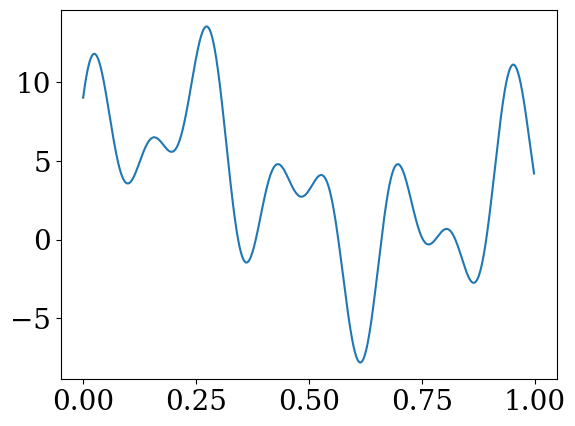

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

#The function to learn
a = [5,4,3,2]
k = [3,2*3.14159,10*2.718,15*3.14159]
def myfunc(x):
    y = a[0]*torch.sin(k[0]*x)
    for i in range(1,len(a)):
        y += a[i]*torch.sin(k[i]*x)
        y += a[i]*torch.cos(k[i]*x)
    return y

#Training data on [0,1] and apply myfunc
data = torch.arange(0,1,0.001).unsqueeze(1)  #Unsqueeze makes it 100x1 instead of 1D length 100
target = myfunc(data)

#Plot the function
fig = plt.figure()
plt.plot(data,target,label='Target Function')

We now construct our one hidden layer neural network in PyTorch.

In [20]:
class Net(nn.Module):
    def __init__(self, num_hidden=1000):
        super(Net, self).__init__()
        self.n = num_hidden
        self.fc1 = nn.Linear(1,num_hidden)
        self.fc2 = nn.Linear(num_hidden,1)

    def forward(self, x):
        x = F.sigmoid(self.fc1(x))
        return self.fc2(x)

The code below trains the network and plots the result. The flag `cuda` controls whether to use the GPU. Notice the data and model must be sent to the GPU, and pulled back to the cpu for plotting and printing. To use the GPU in Colab, go to Edit -> Notebook Settings, and enable the GPU (you'll have to restart the notebook).

Using  cpu
Iteration: 0, Loss: 37.734203
Iteration: 1000, Loss: 12.083502
Iteration: 2000, Loss: 11.828160
Iteration: 3000, Loss: 10.827806
Iteration: 4000, Loss: 9.502531
Iteration: 5000, Loss: 8.748887
Iteration: 6000, Loss: 7.769774
Iteration: 7000, Loss: 6.710455
Iteration: 8000, Loss: 6.714062
Iteration: 9000, Loss: 5.425823


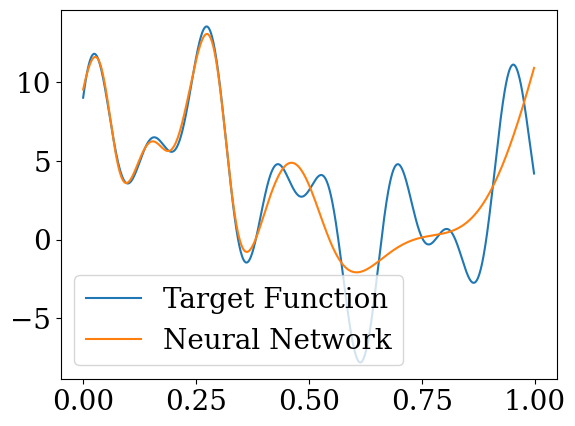

In [21]:
#GPU
cuda = True
use_cuda = cuda and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print('Using ',device)

T = 10000 #Number of training iterations
model = Net(num_hidden=10**3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)  #Learning rate
#optimizer = optim.SGD(model.parameters(), lr=0.001)  #Regular gradient descent (very slow)
data,target = data.to(device), target.to(device)

#Training
model.train()  #Put into training mode
for i in range(T):

    #Zero the gradients
    optimizer.zero_grad()

    #Pass data through model and loss (gradients get accumulated in the optimizer)
    output = model(data)
    loss = torch.mean((output-target)**2)

    #Back propagation to compute all gradients, and an optimizer step
    loss.backward()
    optimizer.step()

    #Print Loss only every 1000 iterations
    if i % 1000 == 0:
        print('Iteration: %d, Loss: %f'%(i,loss.item()))

#Plot the function and neural network
model.eval()
fig = plt.figure()
plt.plot(data.cpu(),target.cpu(),label='Target Function')
plt.plot(data.cpu(),output.detach().cpu(),label='Neural Network')
plt.legend()


Another example in PyTorch:

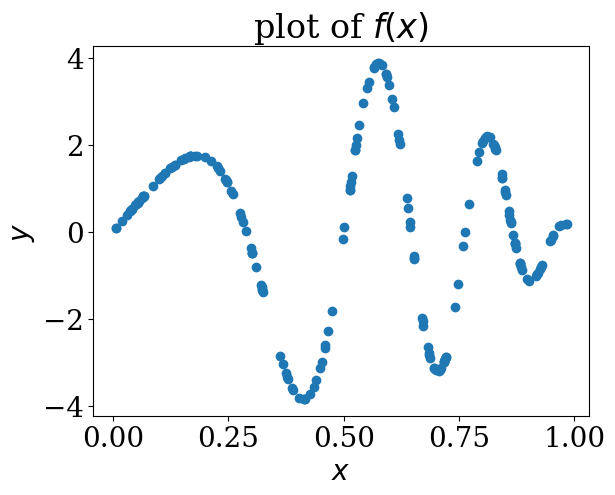

In [22]:
%matplotlib inline

d = 1
n = 200
X = torch.rand(n,d)
y = 4 * torch.sin(np.pi * X) * torch.cos(6*np.pi*X**2)

plt.scatter(X.numpy(), y.numpy())
plt.title('plot of $f(x)$')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.show()

Here we define a simple two hidden layer neural network with Tanh activations. There are a few hyper parameters to play with to get a feel for how they change the results.

In [23]:
# feel free to play with these parameters

step_size = 0.05
n_epochs = 6000
n_hidden_1 = 32
n_hidden_2 = 32
d_out = 1

neural_network = nn.Sequential(
                            nn.Linear(d, n_hidden_1),
                            nn.Tanh(),
                            nn.Linear(n_hidden_1, n_hidden_2),
                            nn.Tanh(),
                            nn.Linear(n_hidden_2, d_out)
                            )

loss_func = nn.MSELoss()

optim = torch.optim.SGD(neural_network.parameters(), lr=step_size)
print('iter,\tloss')
for i in range(n_epochs):
    y_hat = neural_network(X)
    loss = loss_func(y_hat, y)
    optim.zero_grad()
    loss.backward()
    optim.step()

    if i % (n_epochs // 10) == 0:
        print('{},\t{:.2f}'.format(i, loss.item()))



iter,	loss
0,	3.96
600,	3.86
1200,	3.45
1800,	2.11
2400,	1.24
3000,	0.52
3600,	0.36
4200,	0.16
4800,	0.12
5400,	0.10


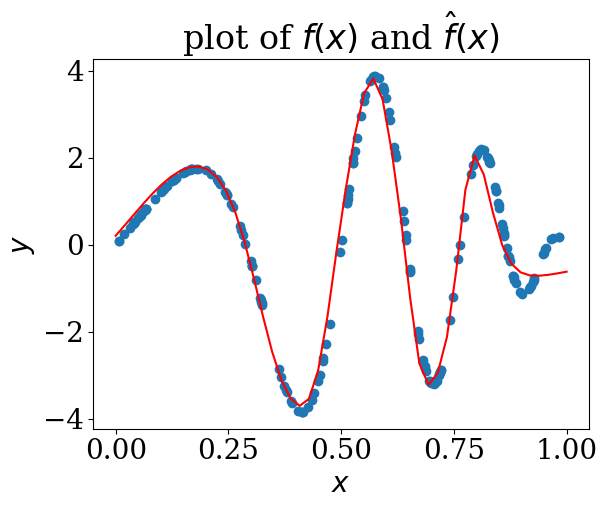

In [24]:
X_grid = torch.from_numpy(np.linspace(0,1,50)).float().view(-1, d)
y_hat = neural_network(X_grid)
plt.scatter(X.numpy(), y.numpy())
plt.plot(X_grid.detach().numpy(), y_hat.detach().numpy(), 'r')
plt.title('plot of $f(x)$ and $\hat{f}(x)$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

Some important PyTorch methods:

* [`torch.nn.Module.parameters()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html): Returns an iterator over module parameters (i.e. for passing to an optimizer that will update those parameters).

* [`torch.Tensor.view()`](https://pytorch.org/docs/stable/generated/torch.Tensor.view.html): Returns a *view* into the original Tensor. The result of this method shares the same underlying data as the input Tensor. This avoids copying the data, which means it can be mnore efficient, but it also means that when the original Tensor is modified, so is the view!

* [`torch.Tensor.item()`](https://pytorch.org/docs/stable/generated/torch.Tensor.item.html#torch.Tensor.item): Returns the value of a single-element Tensor as a standard Python number. This only works for tensors with one element. For other cases, see `torch.Tensor.tolist()`.

* [`torch.Tensor.backward()`](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html): Computes the gradients of current tensor wrt the graph leaves (note that this is only called if `Tensor.requires_grad` is True, which is the case by default). After calling this, a Tensor's `.grad` attribute is updated with the current gradients. These are used, for example, when calling `.step()` method of an optimizer.

* [`torch.optim.Optimizer.zero_grad()`](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html): Sets the gradients of all variables to zero. This should be conducted before each step of an optimization procedure (i.e., for each batch of training a DNN). If `.zero_grad()` is not called, gradients accumulate (add) over iterations.

## Toy classification problem

We now consider a simple toy classification problems in two dimensions.

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ClassifyNet(nn.Module):
    def __init__(self, num_in, num_hidden, num_out):
        super(ClassifyNet, self).__init__()
        self.fc1 = nn.Linear(num_in,num_hidden)
        self.fc2 = nn.Linear(num_hidden,num_out)

    def forward(self, x):
        return F.log_softmax(self.fc2(F.relu(self.fc1(x))), dim=1)

We now train the model for classification and plot the resulting decision boundary. Here, we do not use the GPU since the data sets are small and training is very quick. We first define our usual plot_region function.

In [26]:
def plot_region(X,L,clf,alpha=0.5,cmap='Paired',cp=np.array([0.5,2.5,6.5,8.5,10.5,11.5]),markers = ['o','s','D','^','v','p'],vmin=0,vmax=12,markersize=75,linewidths=1.25,markerlinewidths=1,res=0.01,train_pts=None):

    plt.figure()
    x,y = X[:,0],X[:,1]
    xmin, xmax = np.min(x),np.max(x)
    ymin, ymax = np.min(y),np.max(y)
    f =0.1*np.maximum(np.max(np.abs(x)),np.max(np.abs(y)))
    xmin -= f
    ymin -= f
    xmax += f
    ymax += f
    c = cp[L]
    c_u = np.unique(c)

    for i,color in enumerate(c_u):
        sub = c==color
        plt.scatter(x[sub],y[sub],zorder=2,c=c[sub],cmap=cmap,edgecolors='black',vmin=vmin,vmax=vmax,linewidths=markerlinewidths,marker=markers[i],s=markersize)
        if train_pts is not None:
            plt.scatter(x[sub & train_pts],y[sub & train_pts],zorder=2,c=np.ones(np.sum(sub&train_pts))*5.5,cmap=cmap,edgecolors='black',vmin=vmin,vmax=vmax,linewidths=markerlinewidths,marker=markers[i],s=markersize)


    X,Y = np.mgrid[xmin:xmax:0.01,ymin:ymax:0.01]
    points = np.c_[X.ravel(),Y.ravel()]
    z = clf.predict(points)
    z = z.reshape(X.shape)
    plt.contourf(X, Y, cp[z],alpha=alpha,cmap=cmap,antialiased=True,vmin=vmin,vmax=vmax)

    X,Y = np.mgrid[xmin:xmax:res,ymin:ymax:res]
    points = np.c_[X.ravel(),Y.ravel()]
    if len(np.unique(c)) == 2:

        if hasattr(clf, "decision_function"):
            z = clf.decision_function(points)
        else:
            z = clf.predict_proba(points)
            z = z[:,0] - z[:,1] + 1e-15
        z = z.reshape(X.shape)
        plt.contour(X, Y, z, [0], colors='black',linewidths=linewidths,antialiased=True)
    else:
        z = clf.predict(points)
        z = z.reshape(X.shape)
        plt.contour(X, Y, z, colors='black',linewidths=linewidths,antialiased=True)
    plt.xlim((xmin,xmax))
    plt.ylim((ymin,ymax))


Final Loss=0.000311


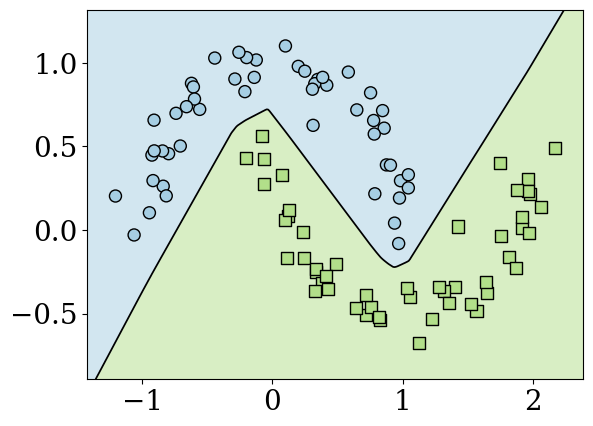

In [27]:
import torch.optim as optim
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np

#Create a Python class so it looks like an sklearn classifier
class NetWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, x):
        with torch.no_grad():
            x = torch.from_numpy(x).float()
            p = self.model(x).numpy()
        return p

    def predict(self, x):
        return np.argmax(self.predict_proba(x),axis=1)

#Data set
n = 100
#X,L = datasets.make_blobs(n_samples=n, cluster_std=[1,1.5], centers=2, random_state=1)
X,L = datasets.make_moons(n_samples=n,noise=0.1,random_state=4)
#X,L = datasets.make_circles(n_samples=n,noise=0.1,random_state=4,factor=0.5)

#Setup model and optimizer
num_hidden = 64 #Number of hidden nodes in the one hidden layer
model = ClassifyNet(2,num_hidden,2)
optimizer = optim.Adam(model.parameters(), lr=0.01)  #Learning rates

#Data to torch
data = torch.from_numpy(X).float()
target = torch.from_numpy(L).long()

#Train for 1000 epochs
model.train()
for i in range(1000):
    optimizer.zero_grad()
    loss = F.nll_loss(model(data), target)
    loss.backward()
    optimizer.step()

print('Final Loss=%f'%loss.item())
model.eval()
plot_region(X,L,NetWrapper(model))

##Application to MNIST digit classification

Another example is to the classification of MNIST digits. While Torch offers access to MNIST and other datasets, we'll use GraphLearning for now.

In [28]:
pip install -q graphlearning

Note: you may need to restart the kernel to use updated packages.


Let's first load MNIST and display some images.

(70000, 784)


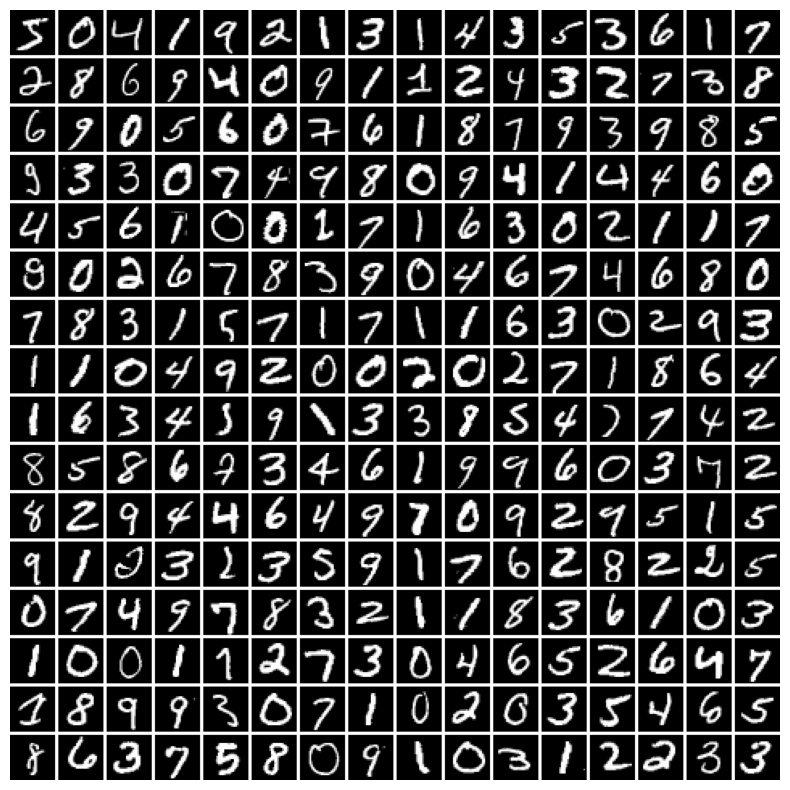

In [29]:
import graphlearning as gl

#Load MNIST data
x,y = gl.datasets.load('mnist')

#Display images
gl.utils.image_grid(x,n_rows=16,n_cols=16)
print(x.shape)

We use a two layer neural network with 64 hidden nodes, and the Adam Optimizer and SGD with batch size 480. You can play around with these parameters and see how the training is affected. We also use the full 60000 training set, but you can experiment with using less training data.

In [30]:
num_hidden = 64
batch_size = 480

#GPU
cuda = True
use_cuda = cuda and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

#Training data (select at random from first 600000)
train_size = 60000
train_ind = np.random.permutation(60000)[:train_size]

#Convert data to torch and device
data_train = torch.from_numpy(x[train_ind,:]).float().to(device)
target_train = torch.from_numpy(y[train_ind]).long().to(device)
data_test = torch.from_numpy(x[60000:,:]).float().to(device)
target_test = torch.from_numpy(y[60000:]).long().to(device)

#Setup model and optimizer
model = ClassifyNet(784,num_hidden,10).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)  #Learning rates

#Training
print('Iteration,Testing Accuracy,Training Accuracy')
for i in range(20):

    #Model evaluation
    model.eval()
    with torch.no_grad():
        pred = torch.argmax(model(data_test),axis=1)
        test_accuracy = torch.sum(pred == target_test)/len(pred)
        pred = torch.argmax(model(data_train),axis=1)
        train_accuracy = torch.sum(pred == target_train)/len(pred)
        print(i,test_accuracy.item()*100,train_accuracy.item()*100)

    #Training mode, run data through neural network in mini-batches (SGD)
    model.train()
    for j in range(0,len(target_train),batch_size):
        optimizer.zero_grad()
        loss = F.nll_loss(model(data_train[j:j+batch_size,:]), target_train[j:j+batch_size])
        loss.backward()
        optimizer.step()

Iteration,Testing Accuracy,Training Accuracy
0 5.530000105500221 5.460000038146973
1 94.35999989509583 94.52000260353088
2 95.74999809265137 96.44166827201843
3 96.42000198364258 97.39500284194946
4 96.53000235557556 97.74333238601685
5 96.74999713897705 98.14333319664001
6 96.90999984741211 98.48833084106445
7 96.97999954223633 98.60333204269409
8 96.82000279426575 98.68666529655457
9 96.85999751091003 98.82000088691711
10 96.50999903678894 98.18833470344543
11 96.70000076293945 98.6133337020874
12 96.7199981212616 98.70166778564453
13 96.5399980545044 98.59333038330078
14 96.92000150680542 98.94499778747559
15 97.0300018787384 99.13666844367981
16 97.15999960899353 99.32166934013367
17 97.02000021934509 99.1100013256073
18 97.3800003528595 99.36333298683167
19 97.00000286102295 99.09999966621399


In order to try to gain some insight into how the network performs, let's plot the weight matrices in the hidden layers. Unfortunately this is not so helpful here.

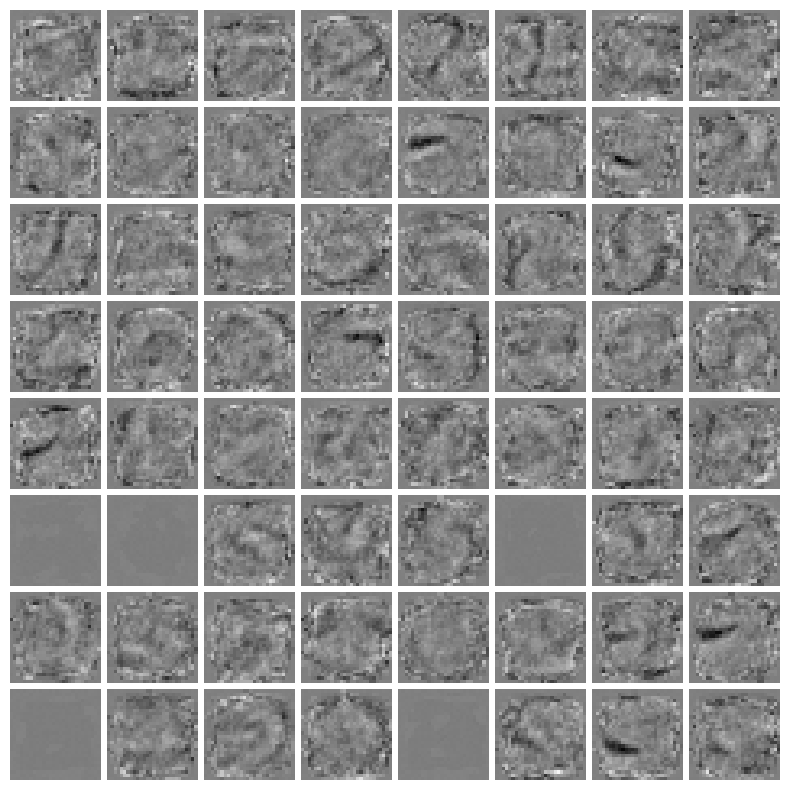

In [31]:
I = model.fc1.weight.detach().cpu().numpy()
I = I/np.max(np.absolute(I))/2 + 0.5
img = gl.utils.image_grid(I,n_rows=8,n_cols=8)

##Exercises
1. Try reducing the train size and see if you can get the network to overfit (which means the training accuracy is much larger than the testing accuracy).
2. Try one of the alternative losses. Show how they compare.
3. Try changing the number of hidden nodes, and the number of layers in the network. How is the accuracy affected?
4. Pick a new classification dataset publicly available online. For example, you can browse [Kaggle](https://www.kaggle.com/) for general data science datasets, [Torch Datasets](https://pytorch.org/vision/stable/datasets.html) for image classification problems, [sklearn datasets](https://scikit-learn.org/stable/datasets.html), or [GraphLearning](https://jwcalder.github.io/GraphLearning/datasets.html#graphlearning.datasets.load). Train a neural network classifier on your new dataset. The code below will get you started with graphlearning.

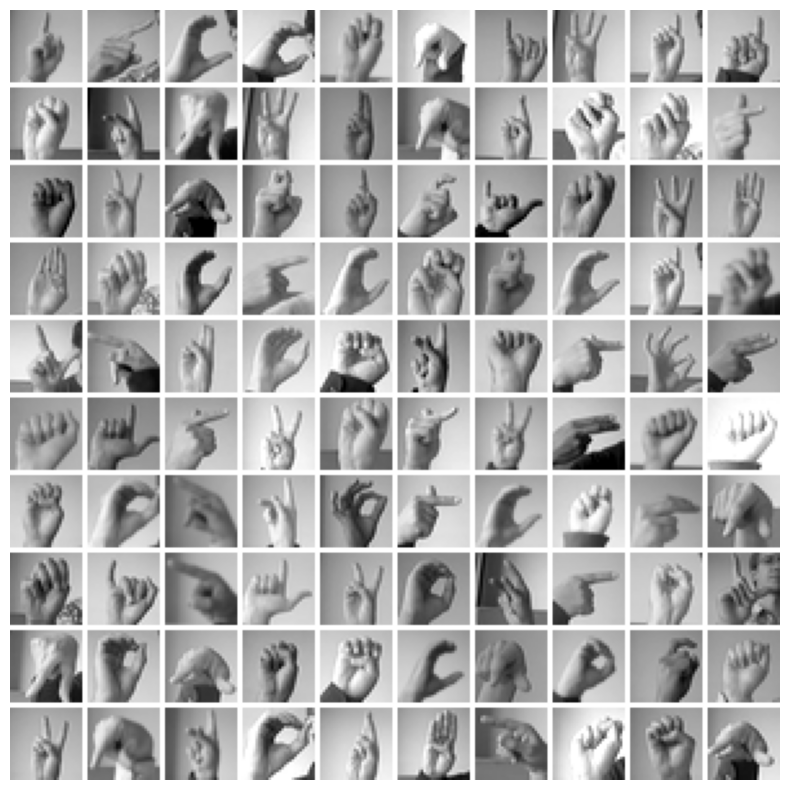

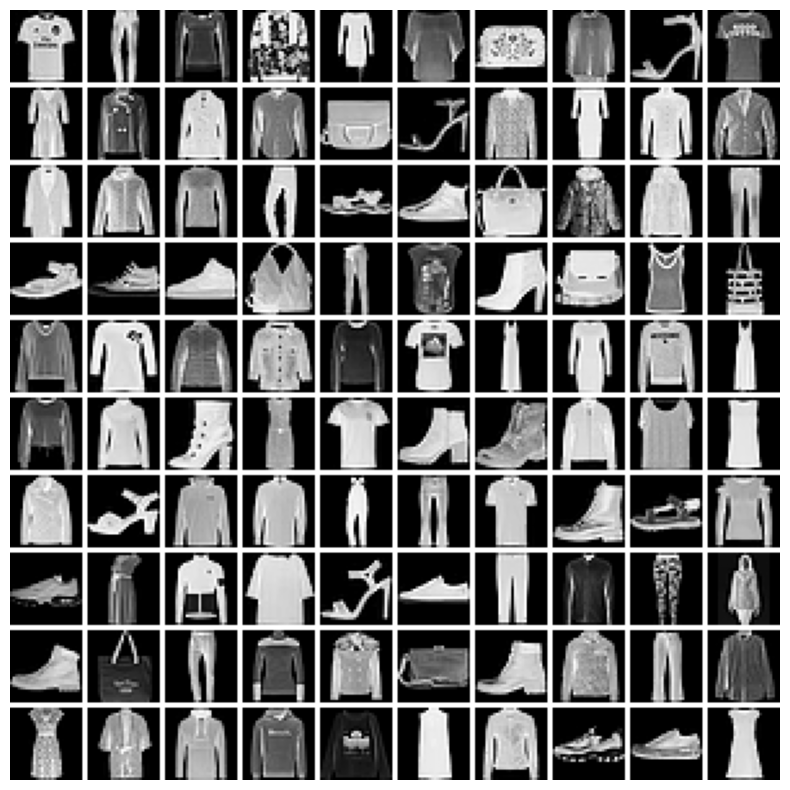

In [32]:
import graphlearning as gl

data,labels = gl.datasets.load('signmnist')
gl.utils.image_grid(data)

data,labels = gl.datasets.load('fashionmnist')
gl.utils.image_grid(data)

